# Validation 2: the Gladman (1993) two-planet limit

Two planets on initially circular orbits can never have close encounters if their separation exceeds 2√3 mutual Hill radii (Gladman 1993). With the mutual Hill radius computed from the mean semi-major axis, as in this code, the limit is 3.35; with the inner planet's semi-major axis it is 3.46. Two planets of 10⁻⁵ M☉ around a solar-mass star are integrated for 5,000 orbits from 8 starting phases at each separation.

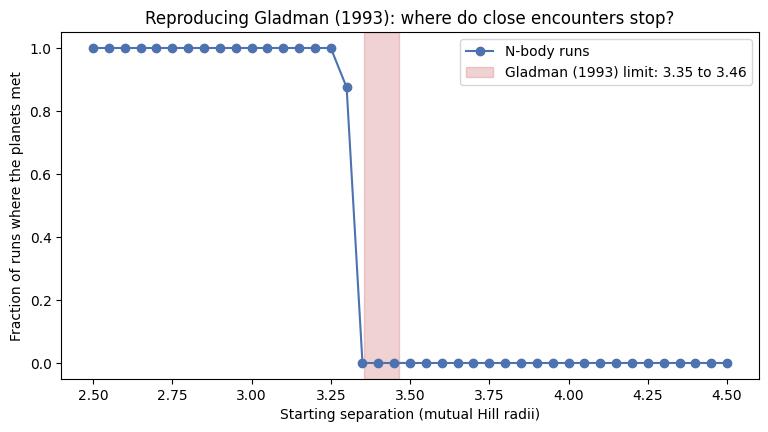

Largest separation where the planets still met: 3.30 Hill radii
Gladman (1993) limit, both conventions:          3.35 to 3.46


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

M_STAR = 1.0      # solar-mass star
M_P = 1e-5        # each planet, in solar masses (about 3 Earth masses)
X = 0.5 * ((2 * M_P) / (3 * M_STAR)) ** (1 / 3)

def planets_meet(delta, start_angle, orbits=5000):
    # True if the planets ever come closer than one mutual Hill radius.
    a1 = 1.0
    a2 = a1 * (1 + delta * X) / (1 - delta * X)    # puts planet 2 exactly 'delta' Hill radii outside planet 1
    hill = ((2 * M_P) / (3 * M_STAR)) ** (1 / 3) * (a1 + a2) / 2
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.add(m=M_STAR)
    sim.add(m=M_P, a=a1, e=0)
    sim.add(m=M_P, a=a2, e=0, l=start_angle)       # l = initial mean longitude of planet 2
    sim.move_to_com()
    sim.integrator = "whfast"
    sim.dt = 0.02 * sim.particles[1].P
    sim.exit_min_distance = hill
    try:
        sim.integrate(orbits * sim.particles[1].P, exact_finish_time=0)
        return False
    except rebound.Encounter:
        return True

deltas = np.arange(2.5, 4.51, 0.05)
angles = np.linspace(0.3, 2 * np.pi, 8, endpoint=False)
fraction_met = [np.mean([planets_meet(d, a) for a in angles]) for d in deltas]

# Gladman's limit for the two Hill-radius conventions (mean or inner semi-major axis).
a_ratio = 1 + 2 * np.sqrt(3) * ((2 * M_P) / (3 * M_STAR)) ** (1 / 3)
LOW, HIGH = 2 * np.sqrt(3) * 2 / (1 + a_ratio), 2 * np.sqrt(3)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(deltas, fraction_met, "o-", color="#4C72B0", label="N-body runs")
ax.axvspan(LOW, HIGH, color="#C44E52", alpha=0.25, label=f"Gladman (1993) limit: {LOW:.2f} to {HIGH:.2f}")
ax.set_xlabel("Starting separation (mutual Hill radii)")
ax.set_ylabel("Fraction of runs where the planets met")
ax.set_title("Reproducing Gladman (1993): where do close encounters stop?")
ax.legend()
plt.savefig("gladman_reproduction.png", dpi=200, bbox_inches="tight")
plt.show()

last_meeting = max((d for d, f in zip(deltas, fraction_met) if f > 0), default=None)
print(f"Largest separation where the planets still met: {last_meeting:.2f} Hill radii")
print(f"Gladman (1993) limit, both conventions:          {LOW:.2f} to {HIGH:.2f}")

**Result.** Close encounters stop between 3.30 and 3.35 mutual Hill radii, matching the analytic limit of 3.35 for this Hill-radius convention.